# Bias Analysis on H-R Diagram with Gaia DR3 data (II)

```Authors: Paul Alvarez updated: 20260721```

This notebooks retrieves a study about the bias in distance-parallax measures. The analyze use Gaia data (via Astroquery) for a selected region of the sky (e.g., Pleiades) and computes stellar absolute magnitudes from parallax measurements, including a discussion about Lutz–Kelker bias associated with estimating distances using the naive inverse-parallax approach (1/parallax), and examines how the resulting Hertzsprung–Russell diagram changes when Bayesian distance estimates are used instead (based on Bailer-Jones paper approach) (This need to change a little bit; with greater enphasis in the analysis (i.e., bayesian distances) rather than compute the H-R diagram...).

## Table of contents:
* [Required libraries](#Required-libraries)
* [Introduction](#introduction)
* [Bailer-Jones Approuch](#bailer-jones-approuch)
* [Interstellar Extinction](#interstellar-extinction)



## Required libraries

In [1]:
!pip install dustmaps

  Using cached dustmaps-1.0.14-py3-none-any.whl.metadata (5.9 kB)
  Using cached healpy-1.19.0.tar.gz (4.1 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached progressbar2-4.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached python_utils-4.0.0-py3-none-any.whl.metadata (14 kB)
Using cached dustmaps-1.0.14-py3-none-any.whl (754 kB)
Using cached progressbar2-4.5.0-py3-none-any.whl (57 kB)
Using cached python_utils-4.0.0-py3-none-any.whl (39 kB)
Failed to build healpy
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for healpy (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [90 lines of output]
      C:\Users\Paul\AppData\Local\Temp\pip-build-env-h989nvgq\overlay\Lib\site-packages\setuptools\_distutils\extension.py:150: UserWarning: Unknown Extension options: 'cython_directives'
        warnings.warn(msg)
      C:\Users\Paul\AppData\Local\Temp\pip-build-env-h989nvgq\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2027-Feb-18, you need to update your project and remove deprecated calls
              or your bu

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
import os

## Introduction 

The Hertzsprung-Russell diagram (HR diagram) is one of the most important tools in the study of stellar evolution. Developed independently in the early 1900s by Ejnar Hertzsprung and Henry Norris Russell, it plots the temperature of stars against their luminosity (the theoretical HR diagram), or the colour of stars (or spectral type) against their absolute magnitude (the observational HR diagram, also known as a colour-magnitude diagram, which we refers in this study).

Depending on its initial mass, every star goes through specific evolutionary stages dictated by its internal structure and how it produces energy. Each of these stages corresponds to a change in the temperature and luminosity of the star, which can be seen to move to different regions on the HR diagram as it evolves. This reveals the true power of the HR diagram – astronomers can know a star’s internal structure and evolutionary stage simply by determining its position in the diagram (COSMOS, Swinburne University of Technology).

However, the utility of the observational H-R diagram in understanding stellar formation and structure relies primarily on the assumption that the magnitude is unbiased (or, at least, not significantly so). In this context, a reliable distance is required to calculate the magnitude; otherwise, additional biases are introduced into the measurement process. This gives rise to the primary motivation for this study: to examine the widely used "naive" distance estimator, 1/ϖ, and its impact on absolute magnitude calculations and the resulting HR diagram, as well as to analyze and implement corrections for the associated biases, such as Bayesian distance estimates. In particular, we explore the construction of the Hertzsprung–Russell (H-R) diagram using Gaia DR3 data for the Pleiades star cluster in order to investigate the effects and limitations of estimating stellar distances from the inverse of the measured parallax, 


## Bayesian inference 

Bailer-Jones (2015) analyzes the problem of distance estimation via parallax inversion by defining $\varpi$ as the observed parallax (in arcseconds) and $r$ as the true distance to a star (in parsecs), as well as the ideal relationship (in the absence of measurement errors):

$$r = \frac{1}{\varpi}$$

Furthermore, it formally define the estimated value and the true value as $r_{true}$, $r_{est}$ (estimate), and the relative or fractional error of the measured parallax:

$$f = \frac{\sigma_{\varpi}}{\varpi}$$

and the true fractional error as:

$$f_{\text{true}} = \sigma_{\varpi} \cdot r_{\text{true}}$$


With this in mind, Bailer-Jones (2015) demonstrates that treating the inverse of the parallax as a distance estimator (i.e., $r_{est} = \frac{1}{\varpi}$) is not trivial once the fractional parallax error exceeds approximately 20%, primarily because the inversion is a non-linear transformation of the measured parallax, causing the resulting uncertainty in the inferred distance to become asymmetric and increasingly skewed toward larger distances.

Then, since the parallax inversion is unstable for $f > 0.2$, the estimation problem becomes one of statistical inference. Accordingly, Bailer-Jones (2015) assumes a Gaussian distribution for $\sigma_{\varpi}$:

$$P(\varpi \mid r, \sigma_{\varpi}) = \frac{1}{\sqrt{2\pi}\sigma_{\varpi}} \exp\left( -\frac{1}{2\sigma_{\varpi}^2} \left( \varpi - \frac{1}{r} \right)^2 \right)$$


Now, since we cannot infer $r$ exactly, we want a probability distribution over the possible values ​​of $r$. That is, we want to find $P(r \mid \varpi, \sigma_{\varpi}) \propto P(\varpi \mid r, \sigma_{\varpi}) \, P(r)$.
From Bayes theorem, this is related to the likelidad by:

$$P(r \mid \varpi, \sigma_{\varpi}) \propto P(\varpi \mid r, \sigma_{\varpi}) \, P(r)$$

Por lo que, el problema se transforma en la construcción de una distribución a priori adecuada para $r$. Dentro de ello, Bailer-Jones (2015), propone una prior que desciende de manera suave y asintótica hacia el infinito: un prior de densidad de volumen decreciente exponencialmente.  

Thus, the problem becomes one of selecting an appropriate prior distribution for the distance $r$. In this context, Bailer-Jones (2015) proposes an exponentially decreasing space-density prior, which assumes that the stellar number density decreases exponentially with distance:

$$P(r) = \frac{r^2}{2L^3} e^{-r/L} \quad (r > 0)$$

where $L > 0$ represents a geometric length scale of the stellar population and the estimator is $r_{est} = r_{mode}$.

In [11]:
# Functions to compute and study the behavior of the posterior
def likelihood(parallax_obs, sigma_parallax, r):
    """
    Gaussian likelihood for the observed parallax.
    Assumes parallax is in arcseconds and distance in parsecs.
    """
    parallax_model = 1.0 / r
    return np.exp(
        -0.5 * ((parallax_obs - parallax_model) / sigma_parallax) ** 2
    ) / (np.sqrt(2 * np.pi) * sigma_parallax)


def prior(r, L):
    """
    Exponentially decreasing space density prior.
    """
    return np.where(r > 0, (r**2 / (2 * L**3)) * np.exp(-r / L), 0.0)


def posterior_normalized(r, parallax_obs, sigma_parallax, L):
    """
    Normalized posterior:
    P(r | ϖ, σϖ) = (likelihood * prior) / normalization factor
    """

    # Unnormalized posterior
    posterior_unnorm = (
        likelihood(parallax_obs, sigma_parallax, r)
        * prior(r, L)
    )

    # Normalization constant
    normalization = np.trapz(posterior_unnorm, r)
    return posterior_unnorm / normalization


In [12]:
# Now, with the posterior_normalizaed already compute
# The r_{est} correspond to the MAP of the distribution
def estimate_distance_MAP(parallax, sigma_parallax, L, r_grid):
    
    posterior = posterior_normalized(
        r_grid,
        parallax,
        sigma_parallax,
        L
    )

    r_MAP = r_grid[np.argmax(posterior)]

    return r_MAP

To determine the value of $L$ to use in this case (Pleiades star cluster), we can use the fact that:

$$
P(r) \propto r^2 e^{-r/L}, \qquad r > 0.
$$


Next, to determine the mode of this distribution, we differentiate the prior with respect to the distance r and set the derivative equal to zero

$$
\frac{d}{dr}\left(r^2 e^{-r/L}\right)
=
2r e^{-r/L}
-
\frac{r^2}{L} e^{-r/L}
=
r e^{-r/L}
\left(
2-\frac{r}{L}
\right)
=0.
$$

Since \(r > 0\), the only physically admissible solution corresponds to

$$
r_{\mathrm{mode}} = 2L.
$$

Por lo tanto, la moda de la distribución a priori se encuentra en una distancia igual al doble del parámetro de escala \(L\). Como conocimiento a priori, podemos planter una distancia al agrupamiento de estrellas de las Pleyádes de $\approx 440$ light-years from Earth (by the refined distance of Hubble Space Telescope in 2004), which means $\approx 135$ pc, y por consiguiente, $L = 135/2$.

Therefore, the mode of the prior distribution is located at a distance equal to twice the scale parameter $L$. As prior knowledge, we consider the distance to the Pleiades star cluster; approximately 440 light-years from Earth, corresponding to about 135 pc, based on the refined distance determined by the Hubble Space Telescope in 2004. We then choose the scale parameter such that the mode of the prior coincides with this distance, yielding $L = 135/2$ pc.

In [13]:
df_gaia = pd.read_csv("../data/df_gaia_processed.csv")

# The assumed distribution now use arcsec instead of mas
df_gaia["parallax_arcsec"] = df_gaia["parallax"] / 1000
df_gaia["parallax_error_arcsec"] = df_gaia["parallax_error"] / 1000
L = 135 / 2  # pleiades aprox distance
r_grid = np.linspace(1, 10000, 20000)


# Compute the inferred distance with bayesian approach
df_gaia["distance_MAP"] = df_gaia.apply(
    lambda row: estimate_distance_MAP(
        row["parallax_arcsec"],
        row["parallax_error_arcsec"],
        L,
        r_grid
    ),
    axis=1
)

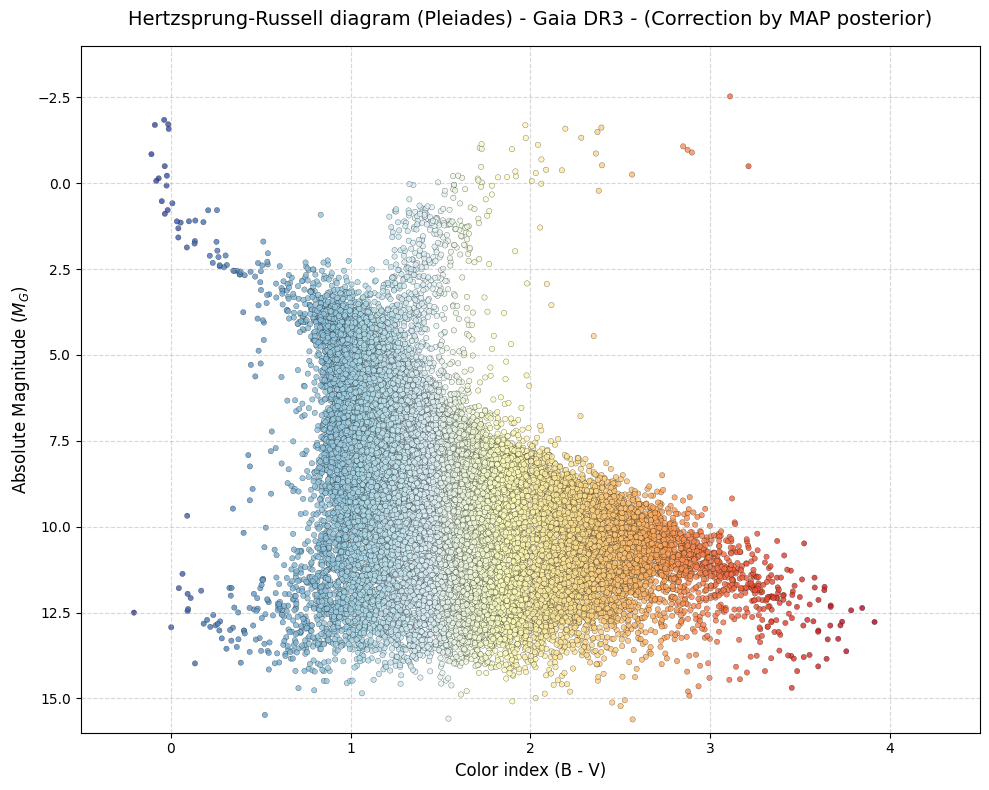

In [14]:
# Calculate the absolute g using the prior approach
pc_distance = df_gaia["distance_MAP"] # Gaia used 'mas' instead of pc
df_gaia['absolute_g_MAP'] = df_gaia['phot_g_mean_mag'] - 5.0 * np.log10(pc_distance) + 5.0 # Absolute and observational magnitude relation

# HR diagram
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_gaia['bp_rp'], df_gaia['absolute_g_MAP'], c=df_gaia['bp_rp'], cmap='RdYlBu_r', 
                s=15, edgecolor='black', linewidths=0.2, alpha=0.8)

# Save figures
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.gca().invert_yaxis()
plt.title('Hertzsprung-Russell diagram (Pleiades) - Gaia DR3 - (Correction by MAP posterior)', fontsize=14, pad=15)
plt.xlabel('Color index (B - V)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.5, 4.5)
plt.ylim(16, -4) 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "hr_diagram_biased_correction_a.png"), dpi=300, bbox_inches="tight")
plt.show()

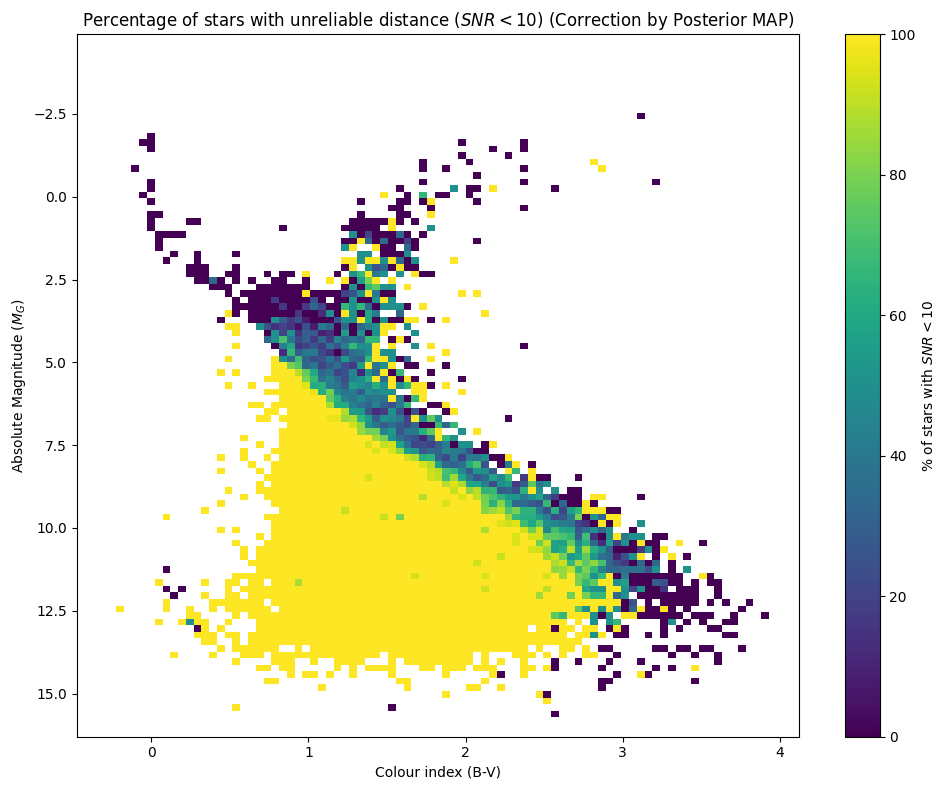

In [16]:
# Stars with unreliable distance
df_gaia["bad_distance"] = df_gaia["parallax_over_error"] < 10
color_bins = np.arange(-0.5, 4.2, 0.05)
mag_bins = np.arange(-5, 16.5, 0.2)

df_gaia["color_bin"] = pd.cut(df_gaia["bp_rp"], color_bins)
df_gaia["mag_bin_MAP"] = pd.cut(df_gaia["absolute_g_MAP"], mag_bins)

# Percentage of stars with unreliable distance 
heat = (df_gaia.groupby(["mag_bin_MAP", "color_bin"], observed=False)["bad_distance"].mean().unstack()* 100)

# Define the axes for coloring each one
x = [i.mid for i in heat.columns] 
y = [i.mid for i in heat.index]

# Plot the HR diagram color by % of stars with SNR < 10 in the corresponding region 
plt.figure(figsize=(10,8))
im = plt.imshow(heat, origin="lower", aspect="auto", extent=[x[0], x[-1], y[0], y[-1]], cmap="viridis", vmin=0, vmax=100)
plt.gca().invert_yaxis()
plt.xlabel(r"Colour index (B-V)")
plt.ylabel(r"Absolute Magnitude ($M_G$)")
plt.title("Percentage of stars with unreliable distance ($SNR<10$) (Correction by Posterior MAP)")
cbar = plt.colorbar(im)
cbar.set_label("% of stars with $SNR<10$")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "hr_diagram_snr_per_region_biased_correction_a.png"), dpi=300, bbox_inches="tight")
plt.show()

## Interstellar Extinction